# Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 1- Load Data

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Chk datatype

In [3]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T

In [4]:
chk_types_table(df)

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,str,float64,int64,str,str,float64
Num_Unique,47,2,548,6,2,4,1337


- **There is no PassengerId/Name/Ticket-like identifier column in this dataset, so no columns need to be dropped.**

In [5]:
cols = ['sex',
        'children',
        'smoker',
        'region']
df[cols] = df[cols].astype('category')


In [6]:
chk_types_table(df)

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,category,float64,category,category,category,float64
Num_Unique,47,2,548,6,2,4,1337


In [7]:
df.shape[0]

1338

### 2- Handle Missing Values

- **Check for Null Values**

In [8]:
null = df.isnull().sum()
ratio = (null / df.shape[0]) * 100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,age,sex,bmi,children,smoker,region,charges
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- **Replace Null Values in numeric columns (none found, kept for consistency with pipeline)**

In [9]:
for col in df.select_dtypes('number').columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)


- **Drop rows with Null in critical categorical columns (none found in this dataset)**

In [10]:
df.dropna(subset=['sex', 'smoker', 'region'], inplace=True)


In [11]:
null = df.isnull().sum()
ratio = (null / df.shape[0]) * 100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,age,sex,bmi,children,smoker,region,charges
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3- Handle Outliers

- **Check for Outliers**

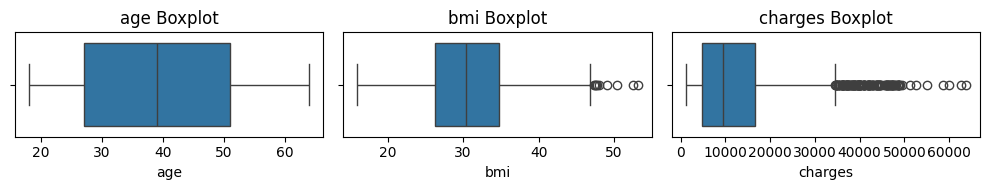

In [12]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(10,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")
plt.tight_layout()
plt.show()

In [13]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    # print(IQR)
    Lower_Fence = Q1 - 1.5*IQR
    Upper_Fence = Q3 + 1.5*IQR

    Lower_Outliers = df[df[col] < Lower_Fence][col].values
    Upper_Outliers = df[df[col] > Upper_Fence][col].values
    df[col].replace(Lower_Outliers, Lower_Fence, inplace=True)
    df[col].replace(Upper_Outliers, Upper_Fence, inplace=True)

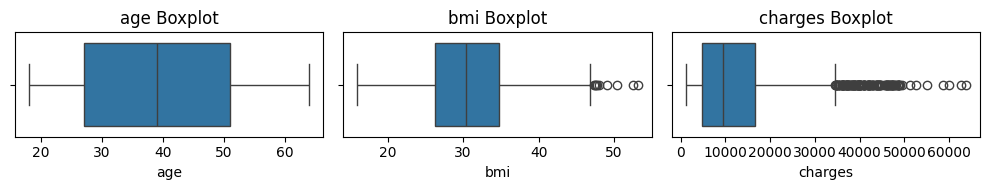

In [14]:
plt.figure(figsize=(10,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")
plt.tight_layout()
plt.show()

### 4- Handle Duplicates

In [15]:
df.duplicated().sum()

np.int64(1)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

np.int64(0)

### 5- Distribution of Numeric Columns

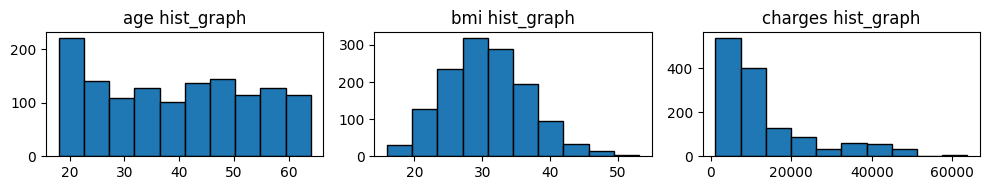

In [18]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(10,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    plt.hist(df[col], edgecolor="black")
    plt.title(f"{col} hist_graph")
plt.tight_layout()
plt.show()

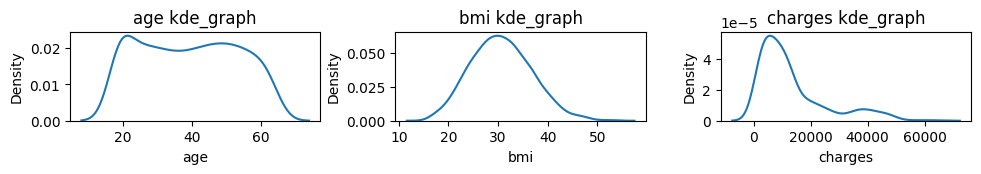

In [19]:
plt.figure(figsize=(10,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} kde_graph")
plt.tight_layout()
plt.show()

### 6- Distribution of Categorical Columns

In [20]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['sex', 'children', 'smoker', 'region'], dtype='str')

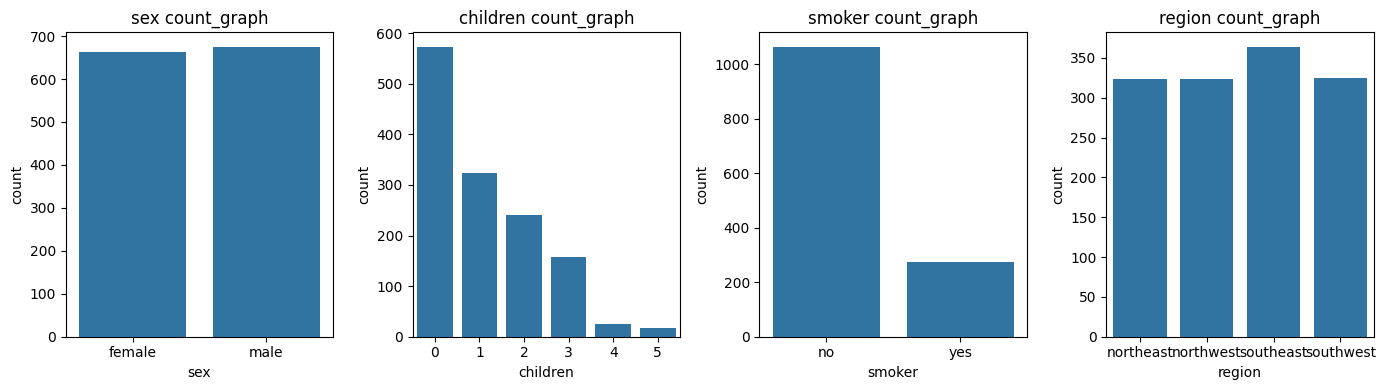

In [21]:
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(1, 4, i+1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} count_graph")
plt.tight_layout()
plt.show()

In [22]:
unique = df['region'].value_counts()
count = unique.values
print(unique)
print(count)

region
southeast    364
southwest    325
northeast    324
northwest    324
Name: count, dtype: int64
[364 325 324 324]


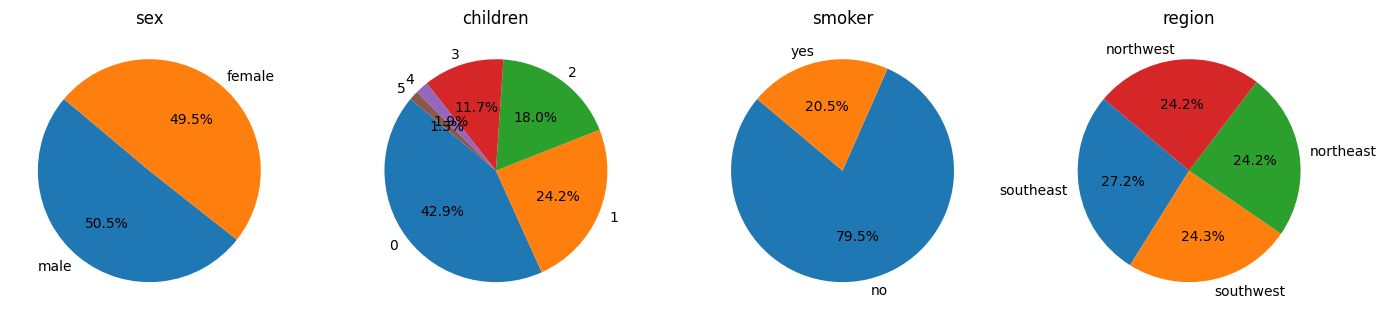

In [23]:
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(1, 4, i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count, labels=categories, startangle=140, autopct='%1.1f%%')
    plt.title(f"{col}")
plt.tight_layout()
plt.show()

### 7- Relationships Between Variables

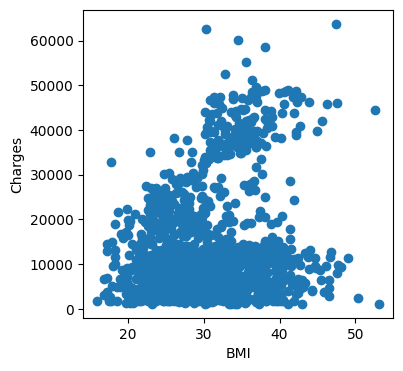

In [24]:
plt.figure(figsize=(4,4))
plt.scatter(df['bmi'], df['charges'])
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

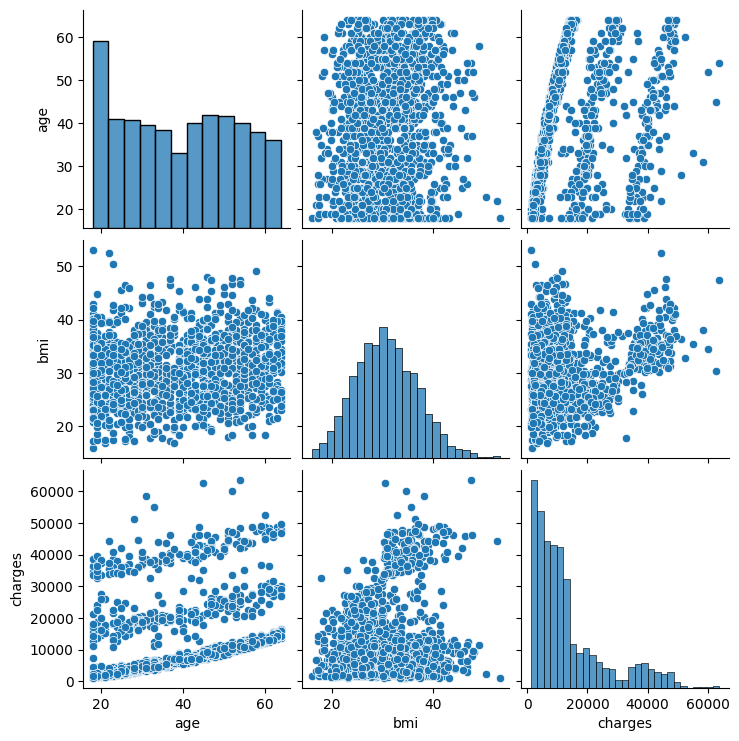

In [25]:
sns.pairplot(df)

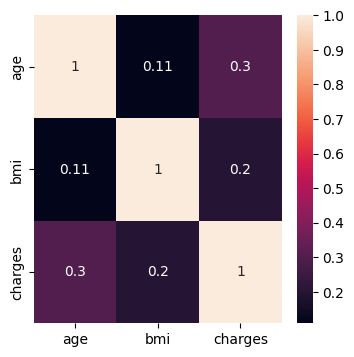

In [26]:
corr = df[num_cols].corr()
plt.figure(figsize=(4,4))
sns.heatmap(corr, annot=True)
plt.show()

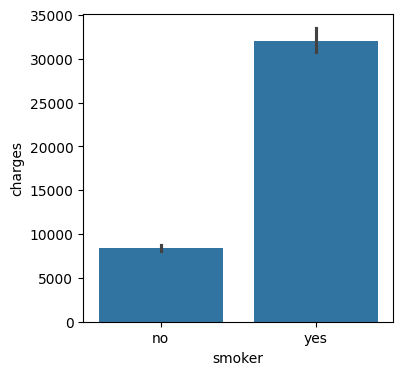

In [27]:
plt.figure(figsize=(4,4))
sns.barplot(x="smoker", y="charges", data=df)
plt.show()

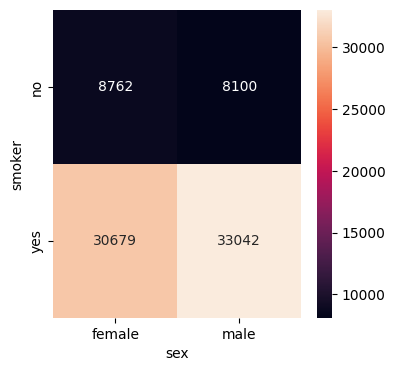

In [28]:
plt.figure(figsize=(4,4))
agg = df.pivot_table(index="smoker", columns="sex", values="charges", aggfunc="mean")
sns.heatmap(agg, annot=True, fmt=".0f")
plt.show()